# Step 15 --- 1D Nonlinear Shallow Water

Adding nonlinearity to the shallow water equations introduces wave
steepening and shock formation. Coriolis coupling ($f_0$) makes
velocity rotate even in 1D.

This tutorial demonstrates:
- Nonlinear wave steepening vs diffusion
- Inertial oscillations from the Coriolis force
- Saving to xarray and creating a GIF

In [1]:
import diffrax as dfx
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from matplotlib.animation import FuncAnimation, PillowWriter

from somax.models import NonlinearShallowWater1D, NonlinearSW1DState

## Model Setup

1D domain, 500 cells, with Coriolis and a small viscosity
to prevent shocks from blowing up.

In [2]:
nx, Lx = 500, 1e6
g, H0, f0 = 9.81, 100.0, 1e-4
model = NonlinearShallowWater1D.create(
    nx=nx, Lx=Lx, g=g, f0=f0, H0=H0, lateral_viscosity=50.0
)

c = float(jnp.sqrt(g * H0))
print(f"Phase speed: {c:.1f} m/s")
print(f"Inertial period: {2 * jnp.pi / f0 / 3600:.1f} hours")

Phase speed: 31.3 m/s
Inertial period: 17.5 hours


## Initial Condition

A tall Gaussian perturbation on top of the mean depth $H_0$.

In [3]:
x = jnp.arange(model.grid.Nx) * model.grid.dx
x0, sigma = Lx / 2.0, Lx / 15.0
h0 = H0 + 2.0 * jnp.exp(-0.5 * ((x - x0) / sigma) ** 2)
u0 = jnp.zeros_like(h0)
v0 = jnp.zeros_like(h0)
state0 = NonlinearSW1DState(h=h0, u=u0, v=v0)

## Integration

In [4]:
t_final = 4e4  # ~11 hours
n_frames = 200
ts = jnp.linspace(0.0, t_final, n_frames)
dt = 0.3 * model.grid.dx / c

sol = model.integrate(state0, t0=0.0, t1=t_final, dt=dt, saveat=dfx.SaveAt(ts=ts))
print(f"All finite: {bool(jnp.all(jnp.isfinite(sol.ys.h)))}")

All finite: True


## Save to xarray

In [5]:
x_km = np.asarray(x[1:-1]) / 1e3
ds = xr.Dataset(
    {
        "h": (["time", "x"], np.asarray(sol.ys.h[:, 1:-1])),
        "u": (["time", "x"], np.asarray(sol.ys.u[:, 1:-1])),
        "v": (["time", "x"], np.asarray(sol.ys.v[:, 1:-1])),
    },
    coords={"time": np.asarray(ts) / 3600.0, "x": x_km},
    attrs={"H0": H0, "f0": f0},
)
ds

<xarray.Dataset> Size: 1MB
Dimensions:  (time: 200, x: 500)
Coordinates:
  * time     (time) float32 800B 0.0 0.05583 0.1117 0.1675 ... 11.0 11.06 11.11
  * x        (x) float32 2kB 2.0 4.0 6.0 8.0 10.0 ... 994.0 996.0 998.0 1e+03
Data variables:
    h        (time, x) float32 400kB 100.0 100.0 100.0 ... 100.0 100.0 100.0
    u        (time, x) float32 400kB 0.0 0.0 0.0 ... -0.01072 -0.0001626
    v        (time, x) float32 400kB 0.0 0.0 0.0 ... -0.009313 0.0003904
Attributes:
    H0:       100.0
    f0:       0.0001

## Create GIF Animation

In [6]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

(line_h,) = ax1.plot(ds.x, ds["h"].isel(time=0), "b-", lw=1.5)
ax1.axhline(H0, color="gray", ls="--", lw=0.5)
ax1.set_ylim(H0 - 1.5, H0 + 2.5)
ax1.set_ylabel("h (m)")
title = ax1.set_title("t = 0.0 h")

(line_u,) = ax2.plot(ds.x, ds["u"].isel(time=0), "r-", lw=1, label="u")
(line_v,) = ax2.plot(ds.x, ds["v"].isel(time=0), "g-", lw=1, label="v")
ax2.set_ylim(-0.5, 0.5)
ax2.set_xlabel("x (km)")
ax2.set_ylabel("velocity (m/s)")
ax2.legend(loc="upper right")


def update(frame):
    line_h.set_ydata(ds["h"].isel(time=frame).values)
    line_u.set_ydata(ds["u"].isel(time=frame).values)
    line_v.set_ydata(ds["v"].isel(time=frame).values)
    title.set_text(f"t = {ds.time.values[frame]:.1f} h")
    return line_h, line_u, line_v, title


anim = FuncAnimation(fig, update, frames=n_frames, interval=50, blit=True)
anim.save("step15_shallow_water_1d.gif", writer=PillowWriter(fps=20), dpi=80)
plt.close()

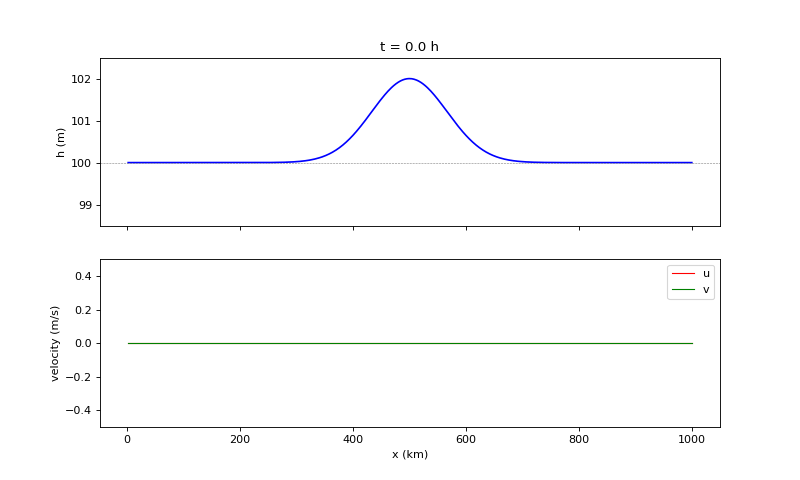

In [7]:
from IPython.display import Image, display

display(Image(filename="step15_shallow_water_1d.gif"))

## Differentiability

In [8]:
import equinox as eqx


@eqx.filter_grad
def grad_fn(m):
    sol = m.integrate(state0, t0=0.0, t1=1000.0, dt=dt)
    return jnp.sum(sol.ys.h**2)


grads = grad_fn(model)
print(f"d(loss)/d(viscosity) = {float(grads.params.lateral_viscosity):.6f}")

d(loss)/d(viscosity) = 0.000002


## Summary

- Nonlinear terms cause wave steepening (taller waves travel faster)
- Coriolis coupling generates a v-velocity from u through inertial oscillations
- Viscosity prevents shock formation

**Next:** [Step 16 --- 2D Geostrophic Adjustment](step16_geostrophic_adjustment.py)